# Grenswaardes voor alarmering

## Een grenswaarde bepalen
Na diep nadenken en rondzoeken op het internet naar reeds toegepaste methodes voor soortgelijke vraagstukken ben ik op de Soil Moisture Index gekomen. In fase 1 was het voorstel om een percentage van de laagste sensorwaarde te nemen. Dit is een goed begin, maar vrij abstract. Een Soil Moisture Index is robuuster in de interpretatie, en biedt meer ruimte voor vervolgonderzoek.

De index heeft de volgende vorm:

SMI = (θ - θVP) / (θGC - θVP)

Waarbij θ het huidige vochtniveau in de grond is, θVP (verwelkingspunt) het punt is waarop planten geen voldoende vocht meer uit de grond kunnen opnemen, en θGC (grondcapaciteit) de maximale hoeveelheid vocht is die de grond vast kan houden.

Deze vorm heeft het effect dat alle gemeten waardes tussen 0 (verwelkingspunt), en 1 (grondcapaciteit) komen te liggen. Er kan dus makkelijk gesproken worden van maximaal natte grond bij een waarde van 1, en een te droge grond bij 0.

### Verwelkingspunten en grondcapaciteit bepalen
Idealiter zou per stuk land waar gewaterd wordt bekend zijn wat voor grond het is waardoor we in een laboratorium kunnen bepalen wat de maximale capaciteit van die grondsoort is. Ook zouden we idealiter weten welke planten er staan, en bij welk bodemvochtgehalte die beginnen te verwelken. Helaas is die data niet beschikbaar, en valt het ook niet binnen de capaciteiten van de gemeente om die te voorzien. Wel kunnen deze waarden benaderd worden.

**Deductief**

Om een snelle, maar waarschijnlijk onnauwkeurige schatting te maken van θVP en θGP kan men de onderste 5% en bovenste 95% van de sensorwaarden nemen. Als er genoeg data is over genoeg verschillende omstandigheden zou de laagste waarde van de sensor een kurkdroge grond aan moeten geven, en de 5% van waardes daarboven zijn dan waarschijnlijk te droog voor de planten om in te overleven. Dit wordt dan het verwelkingspunt θVP. Eveneens zou de bovenste waarde van de sensor een compleet doordrenkte grond aan moeten geven, en de 5% daaronder zou grond aangeven die zeer weinig tot geen capaciteit meer heeft voor water. Dit wordt dan de grondcapaciteit θGC.

**Inductief**

Een langzamere, maar mogelijk meer nauwkeurige manier om θVP en θGC te bepalen is door de sensorwaarden op bepaalde momenten te vergelijken met de mening van een expert. Als een expert bijvoorbeeld aangeeft dat de planten in een bepaald gebied zeer binnenkort zullen gaan verwelken, kan dit vergeleken worden met de sensorwaarde van dat moment. Na deze situatie een aantal keer te hebben vergeleken met de sensorwaarden kan er een aardige inschatting gemaakt worden van het verwelkingspunt θVP. Eveneens kan er na hevige regenval nagegaan worden of er water blijft staan op de grond, waarna redelijkerwijs aangenomen kan worden dat de grond geen capaciteit meer heeft om dit water op te nemen. Deze overeenkomende waarde van de sensor kan dan genomen worden als de grondcapaciteit θGC.

### Deductieve verwelkingspunten en grondcapaciteiten

In de onderstaande grafiek zijn de θVP en θGC van een aantal sensoren bepaald, samen met de huidige grondvochtwaarde θ.

In [3]:
import sqlite3
import pandas as pd
import numpy as np

# --- your inputs ---
device_ids = [1385, 1390, 1391, 1392, 1432]  # Alle sensoren geplaatst op 18-07, behalve Wijnbes

# --- connect & query (includes probe_number + depth columns) ---
conn = sqlite3.connect("multi_probe_data/database.db")
device_ids_str = ",".join(map(str, device_ids))

# (no trailing comma after F.timestamp, you're welcome)
query = f"""
SELECT
    F.device_id,
    D.location_name,
    F.probe_number,
    D.mp_depth_1,
    D.mp_depth_2,
    D.mp_depth_3,
    F.relative_permittivity,
    F.timestamp
FROM FactSensorData F
LEFT JOIN DimSensor D
    ON F.device_id = D.device_id
WHERE F.device_id IN ({device_ids_str})
ORDER BY D.location_name, F.device_id, F.probe_number, F.timestamp;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# --- fix dtypes ---
# relative_permittivity -> numeric
s = df["relative_permittivity"].astype(str).str.strip()
s = s.str.replace(r"\s+", "", regex=True)                                  # weird spaces
s = s.str.replace(r"(?<=\d)[, ](?=\d{3}\b)", "", regex=True)               # thousands sep
s = s.str.replace(",", ".", regex=False)                                   # decimal comma -> dot
df["relative_permittivity"] = pd.to_numeric(s, errors="coerce")

# --- convert timestamp (epoch seconds) to datetime, rounded to the minute ---
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True).dt.floor("min")

# --- compute bottom 5% & top 95% per sensor x probe ---
group_cols = ["device_id", "location_name", "probe_number"]

vals = df.dropna(subset=["relative_permittivity"])

q = (
    vals
    .groupby(group_cols, dropna=False)["relative_permittivity"]
    .quantile([0.05, 0.95])
    .unstack()
    .rename(columns={0.05: "p05", 0.95: "p95"})
    .reset_index()
)

counts = (
    vals
    .groupby(group_cols, dropna=False)["relative_permittivity"]
    .size()
    .rename("n")
    .reset_index()
)

summary = (
    q.merge(counts, on=group_cols, how="left")
     .sort_values(["location_name", "device_id", "probe_number"])
     .reset_index(drop=True)
)

# --- attach probe depths (mp_depth_1/2/3 -> probe_number 1/2/3) ---
depth_cols = [c for c in df.columns if c.startswith("mp_depth_")]
depth_base = df[["device_id", "location_name"] + depth_cols].drop_duplicates()

depth_long = (
    depth_base
    .melt(id_vars=["device_id", "location_name"], value_vars=depth_cols,
          var_name="depth_col", value_name="probe_depth")
)
depth_long["probe_number"] = depth_long["depth_col"].str.extract(r"(\d+)").astype(int)
depth_long = depth_long.drop(columns=["depth_col"])

# coerce probe_depth numeric too (commas, spaces, etc.)
if depth_long["probe_depth"].dtype == object:
    d = depth_long["probe_depth"].astype(str).str.strip()
    d = d.replace({"": None})
    d = d.str.replace(r"\s+", "", regex=True)
    d = d.str.replace(",", ".", regex=False)
    depth_long["probe_depth"] = pd.to_numeric(d, errors="coerce")

summary = (
    summary.merge(
        depth_long,
        on=["device_id", "location_name", "probe_number"],
        how="left"
    )
    .rename(columns={"probe_depth": "probe_depth_from_dim"})
)

# --- most recent value per sensor x probe ---
# drop rows with missing timestamps so "most recent" actually means something
vals_ts = vals.dropna(subset=["timestamp"]).copy()

idx_latest = vals_ts.groupby(group_cols)["timestamp"].idxmax()
latest = (
    vals_ts.loc[idx_latest, group_cols + ["relative_permittivity", "timestamp"]]
           .rename(columns={
               "relative_permittivity": "latest_relative_permittivity",
               "timestamp": "latest_timestamp"
           })
)

summary = summary.merge(latest, on=group_cols, how="left")

# --- SMI = (latest - p05) / (p95 - p05) ---
den = summary["p95"] - summary["p05"]
with np.errstate(invalid="ignore", divide="ignore"):
    summary["smi_raw"] = (summary["latest_relative_permittivity"] - summary["p05"]) / den

# if p95 == p05, smi is undefined
summary.loc[~np.isfinite(summary["smi_raw"]), "smi_raw"] = np.nan

# optional: clipped to [0, 1] for sanity (keep both, pick your poison)
summary["smi_clipped_0_1"] = summary["smi_raw"].clip(lower=0, upper=1)

# final pretty order
result_with_depth_and_smi = (
    summary[
        [
            "device_id", "location_name", "probe_number",
            "probe_depth_from_dim",
            "n", "p05", "p95",
            "latest_timestamp", "latest_relative_permittivity",
            "smi_raw", "smi_clipped_0_1"
        ]
    ]
    .sort_values(["location_name", "device_id", "probe_number"])
    .reset_index(drop=True)
)

# ta-da
result_with_depth_and_smi


,device_id,location_name,probe_number,probe_depth_from_dim,n,p05,p95,latest_timestamp,latest_relative_permittivity,smi_raw,smi_clipped_0_1
0,1391,gabriel_metzusstraat,1,15.0,740,5.13,11.2700,2025-11-21 01:14:00+00:00,11.67,1.065147,1.000000
1,1391,gabriel_metzusstraat,2,50.0,740,9.76,14.2120,2025-11-21 01:14:00+00:00,14.40,1.042228,1.000000
2,1392,ing_driessenstraat,1,15.0,729,16.93,26.2200,2025-11-21 04:08:00+00:00,18.51,0.170075,0.170075
3,1392,ing_driessenstraat,2,50.0,729,31.00,54.1500,2025-11-21 04:08:00+00:00,31.00,0.000000,0.000000
4,1392,ing_driessenstraat,3,70.0,729,14.33,22.5020,2025-11-21 04:08:00+00:00,21.94,0.931229,0.931229
5,1390,lelie_lindestraat,1,15.0,718,6.42,13.2800,2025-11-21 04:07:00+00:00,13.28,1.000000,1.000000
6,1390,lelie_lindestraat,2,50.0,718,11.91,18.4100,2025-11-21 04:07:00+00:00,15.95,0.621538,0.621538
7,1390,lelie_lindestraat,3,70.0,718,11.48,16.8200,2025-11-21 04:07:00+00:00,17.05,1.043071,1.000000
8,1385,park_de_put,1,15.0,796,5.25,12.3675,2025-11-21 02:08:00+00:00,13.57,1.168950,1.000000
9,1385,park_de_put,2,30.0,796,10.40,14.3700,2025-11-21 02:08:00+00:00,18.10,1.939547,1.000000


Zoals te zien is, kan de θVP en θGC niet alleen per sensor, maar ook per probe verschillen. Om een goed beeld te krijgen van de grondvochtigheid van een gebied en zo een goed alarm te kunnen stellen zijn er twee opties:

1. De probes op verschillende dieptes worden los van elkaar gehouden. Op deze manier kunnen alarmen gesteld worden op de droogte van de bovenste laag grond voor de kleinere planten, en los daarvan op de diepere lagen grond voor de grotere planten en bomen.
2. Er wordt een gewogen gemiddelde gegeven van de SMI van een sensor, wat een totaalbeeld geeft van de droogte van dat gebied. Hierdoor zal een drogere toplaag geen alarmen doen afgaan op het moment dat er nog genoeg water aanwezig is in diepere lagen.

In de tabel hieronder is het gewogen gemiddelde van verschillende sensoren weergegeven

In [3]:
import numpy as np
import pandas as pd

# ---- PARAMETERS YOU CAN TWEAK ----
# which SMI to use: 'smi_clipped_0_1' or 'smi_raw'
SMI_COL = "smi_clipped_0_1"

# base weights per probe number (use whatever you want; they'll be renormalized over present probes)
BASE_WEIGHTS = {1: 0.5, 2: 0.3, 3: 0.2}

# ----------------------------------

def _normalized_weights_for_present_probes(present_probes, base_weights):
    # pick only present probes
    base = {p: float(base_weights.get(p, 0.0)) for p in present_probes}
    total = sum(base.values())
    if total <= 0:  # if all zeros/missing, fall back to equal weights among present probes
        return {p: 1.0 / len(present_probes) for p in present_probes}
    return {p: w / total for p, w in base.items()}

def _weighted_avg_group(g: pd.DataFrame, smi_col: str, base_weights: dict):
    g = g.dropna(subset=[smi_col]).copy()
    if g.empty:
        return pd.Series({
            "weighted_smi": np.nan,
            "probes_used": 0,
            "weights_used_p1": np.nan,
            "weights_used_p2": np.nan,
            "weights_used_p3": np.nan,
        })

    present = g["probe_number"].astype(int).tolist()
    w_norm = _normalized_weights_for_present_probes(present, base_weights)

    # align weights to rows
    g["w"] = g["probe_number"].map(w_norm).astype(float)

    # compute weighted average
    weighted_smi = np.average(g[smi_col].values, weights=g["w"].values)

    # expose which weights were actually used (helpful for debugging/missing probes)
    weights_used = {1: np.nan, 2: np.nan, 3: np.nan}
    for p in set([1,2,3]).intersection(w_norm.keys()):
        weights_used[p] = w_norm[p]

    return pd.Series({
        "weighted_smi": weighted_smi,
        "probes_used": len(present),
        "weights_used_p1": weights_used[1],
        "weights_used_p2": weights_used[2],
        "weights_used_p3": weights_used[3],
    })

# group by sensor (device_id), keep location_name for readability
if "result_with_depth_and_smi" not in globals():
    raise NameError("I need the previous cell's `result_with_depth_and_smi` DataFrame. Run that first.")

weighted_smi_by_sensor = (
    result_with_depth_and_smi
    .groupby(["device_id", "location_name"], as_index=False)
    .apply(lambda g: _weighted_avg_group(g, SMI_COL, BASE_WEIGHTS), include_groups=False)
    .reset_index(level=0, drop=True)
    .reset_index()
    .sort_values(["location_name", "device_id"], ignore_index=True)
)


# this is your final summary: one row per sensor with the weighted SMI
weighted_smi_by_sensor


,index,device_id,location_name,weighted_smi,probes_used,weights_used_p1,weights_used_p2,weights_used_p3
0,2,1391,gabriel_metzusstraat,1.000000,2.0,0.625,0.375,NaN
1,3,1392,ing_driessenstraat,0.271283,3.0,0.500,0.300,0.2
2,1,1390,lelie_lindestraat,0.886462,3.0,0.500,0.300,0.2
3,0,1385,park_de_put,1.000000,2.0,0.625,0.375,NaN
4,4,1432,van_der_paauwkade,0.842032,2.0,0.625,0.375,NaN


## Alarmering

Het uiteindelijke doel van dit project is om de gemeente te wijzen op de plekken waar gesproeid moet worden, vooral zodat er niet gesproeid wordt op de plekken waar dit niet nodig is. Dit bespaart water en mankracht, en daarmee geld. De vraag moet zodoende beantwoord worden wanneer het alarm afgaat voor een gebied. Dit zou simpelweg kunnen gebeuren op het moment dat een enkele arbitraire grenswaarde wordt bereikt, maar de onderliggende vraag die daarmee eigenlijk wordt beantwoord is "Wanneer moet er weer gesproeid worden?". Bij het afgaan van het alarm is dat antwoord "Nu". Om direct in de vraag in te spelen stel ik een aantal alarmgrenzen voor die afhankelijk zijn van de hoeveelheid tijd die de gemeente waarschijnlijk heeft totdat het verwelkingspunt wordt bereikt. Hiervoor zijn een aantal datapunten nodig:

    1. Wat is het huidige vochtniveau?
    2. Hoe ontwikkelt dit niveau zich als het droog blijft?
    3. Hoe ontwikkelt dit niveau zich als het gaat regenen?
    4. Gaat het regenen?
    5. Hoeveel regen gaat er vallen?

Als deze vragen beantwoord zijn kan een schatting gemaakt worden wanneer het verwelkingspunt bereikt zal worden, en gebaseerd op die hoeveelheid tijd kan er een alarm afgaan.

### Hoe ontwikkelt het vochtniveau zich tijdens droogte?
De onderstaande grafieken laten zien hoe de sensorwaarden zich gedragen over een periode van droogte en regenval.

Tabel 1 en 2 daaronder geven per sensor aan hoeveel die gemiddeld daalt over dagen dat het niet regent.

Tabel 3 geeft per sensor aan hoeveel die gemiddeld stijgt op het moment dat het heeft geregend.

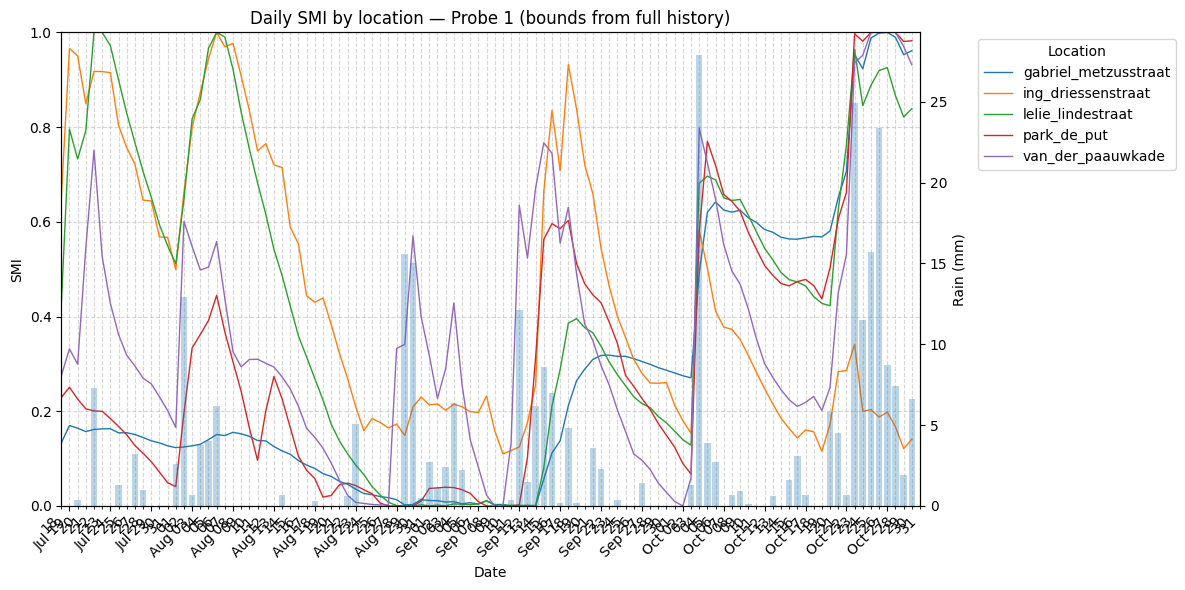

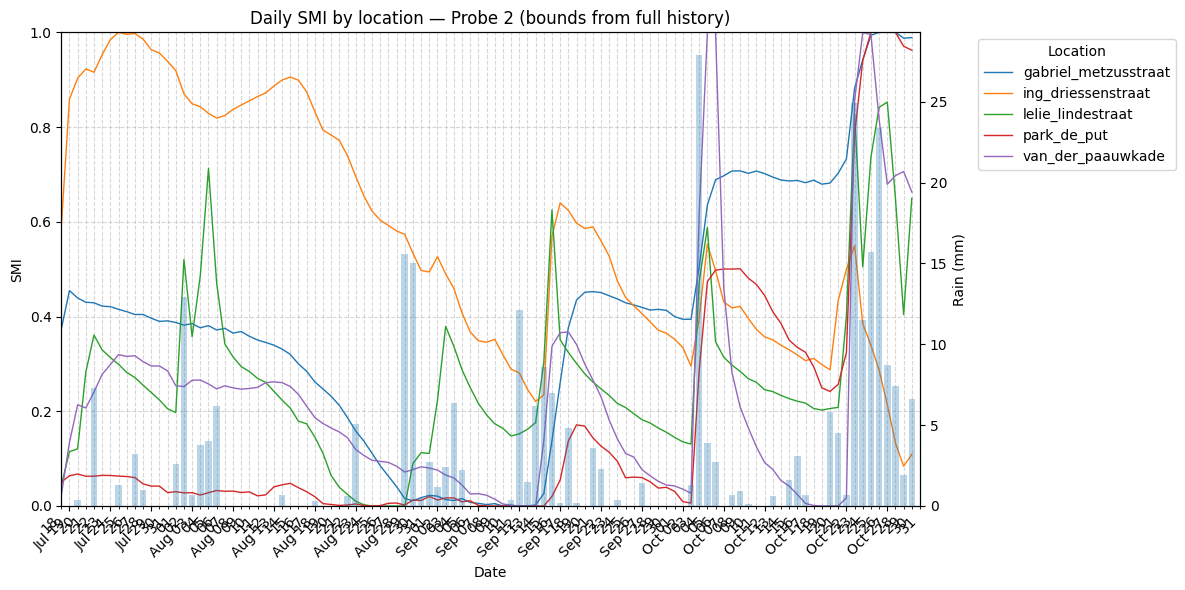

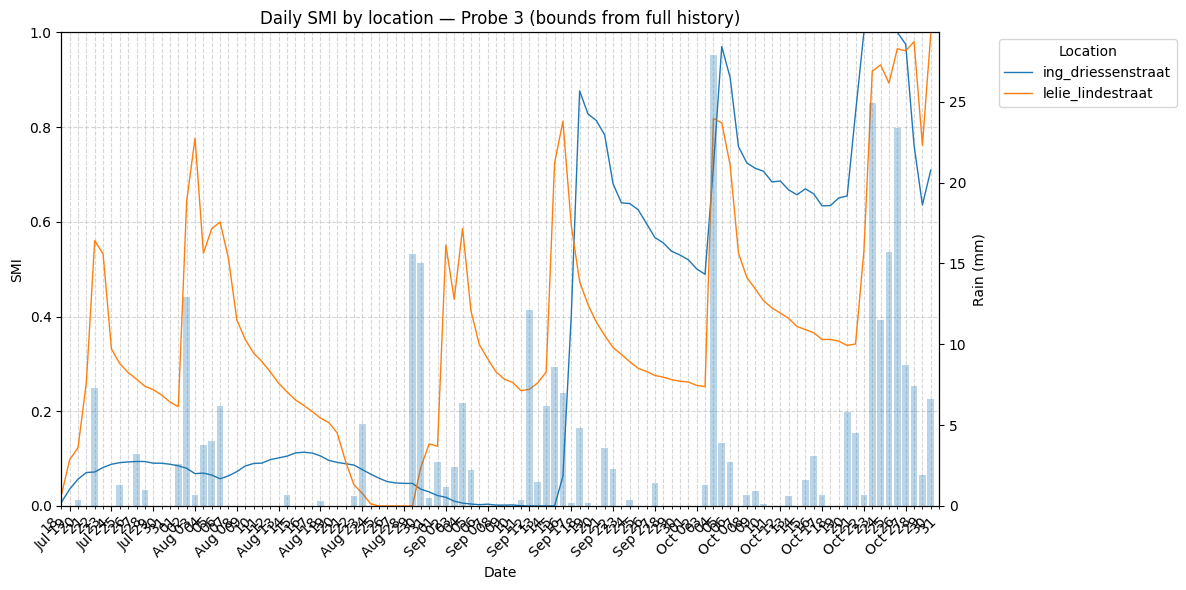

In [9]:
# --- deps ---
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- params ---
device_ids = [1385,1390,1391,1392,1432]
date_from = '2025-07-18'
date_to   = '2025-10-31'
PROBES = [1,2,3]       # we'll try these in order
CLIP_SMI = True        # clip SMI to [0,1] on plots

# --- 1) LOAD *ALL* DATA FOR ALL PROBES (no window here!) ---
conn = sqlite3.connect("multi_probe_data/database.db")
device_ids_str = ",".join(map(str, device_ids))
query = f"""
SELECT
    F.device_id,
    D.location_name,
    F.probe_number,
    F.relative_permittivity,
    F.timestamp
FROM FactSensorData F
LEFT JOIN DimSensor D
    ON F.device_id = D.device_id
WHERE F.device_id IN ({device_ids_str})
  AND F.probe_number IN (1,2,3)
ORDER BY D.location_name, F.device_id, F.probe_number, F.timestamp;
"""
df_all = pd.read_sql_query(query, conn)
conn.close()

# --- 2) CLEAN TYPES ---
# relative_permittivity -> numeric
s = df_all["relative_permittivity"].astype(str).str.strip()
s = s.str.replace(r"\s+", "", regex=True)
s = s.str.replace(r"(?<=\d)[, ](?=\d{3}\b)", "", regex=True)  # thousands sep
s = s.str.replace(",", ".", regex=False)                      # decimal comma
df_all["relative_permittivity"] = pd.to_numeric(s, errors="coerce")

# epoch seconds -> datetime to minute (naive for display)
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], unit="s", utc=True).dt.floor("min")
df_all["timestamp"] = df_all["timestamp"].dt.tz_localize(None)

# --- 3) RAIN DATA (window only for plotting) ---
rain_df = pd.read_csv("multi_probe_data/valkenburg_precipitation.csv")
rain_df.columns = rain_df.columns.str.strip()
rain_df["RD"] = rain_df["RD"] / 10.0  # tenth-mm -> mm
rain_df["date"] = pd.to_datetime(rain_df["DATE"]).dt.normalize()
rain_window = rain_df.loc[
    (rain_df["date"] >= pd.to_datetime(date_from)) &
    (rain_df["date"] <= pd.to_datetime(date_to)),
    ["date", "RD"]
].drop_duplicates(subset="date")

# --- 4) COMPUTE SMI BOUNDS OVER *ALL* DATA PER (location, probe) ---
bounds_alltime = (
    df_all.dropna(subset=["relative_permittivity"])
         .groupby(["location_name","probe_number"])["relative_permittivity"]
         .quantile([0.05, 0.95])
         .unstack()
         .rename(columns={0.05: "p05", 0.95: "p95"})
         .reset_index()
)

# --- 5) TRANSFORM *ALL* READINGS TO SMI USING ALL-TIME BOUNDS ---
df_all = df_all.merge(bounds_alltime, on=["location_name","probe_number"], how="left")
den = (df_all["p95"] - df_all["p05"]).replace(0, np.nan)
df_all["smi_raw"] = (df_all["relative_permittivity"] - df_all["p05"]) / den
df_all.loc[~np.isfinite(df_all["smi_raw"]), "smi_raw"] = np.nan
df_all["smi"] = df_all["smi_raw"].clip(0, 1) if CLIP_SMI else df_all["smi_raw"]

# --- 6) NOW SLICE TO WINDOW FOR DISPLAY, PER PROBE ---
start = pd.to_datetime(date_from)
end   = pd.to_datetime(date_to)

for probe in PROBES:
    df_probe = df_all[df_all["probe_number"] == probe].copy()
    if df_probe.empty:
        # no such probe among these sensors—skip
        continue

    # window for plotting only
    dfp = df_probe[(df_probe["timestamp"] >= start) & (df_probe["timestamp"] <= end)].copy()
    if dfp.empty:
        # probe exists historically but nothing in the window—skip the plot
        continue

    # daily mean SMI per location in the window
    dfp["date"] = dfp["timestamp"].dt.normalize()
    smi_mean_by_day = (
        dfp.groupby(["location_name", "date"])["smi"]
           .mean()
           .reset_index()
    )

    # wide table for lines
    smi_wide = (
        smi_mean_by_day
        .pivot_table(index="date", columns="location_name", values="smi", aggfunc="mean")
        .sort_index()
    )
    if smi_wide.empty:
        continue  # nothing to plot

    # align rain to x-axis
    rain_series = (
        rain_window.set_index("date")["RD"]
        .reindex(smi_wide.index)
    )

    # --- plot one figure per probe ---
    fig, ax1 = plt.subplots(figsize=(12, 6))
    smi_wide.plot(ax=ax1, linewidth=1)
    ax1.set_xlabel("Date")
    ax1.set_ylabel("SMI")
    ax1.set_ylim(0, 1 if CLIP_SMI else None)
    ax1.set_title(f"Daily SMI by location — Probe {probe} (bounds from full history)")

    ax1.set_xlim(start, end)
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax1.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax1.xaxis.set_minor_formatter(mdates.DateFormatter("%d"))
    plt.setp(ax1.get_xticklabels(minor=False), rotation=45, ha="right")
    plt.setp(ax1.get_xticklabels(minor=True), rotation=45, ha="right")
    ax1.grid(which="both", linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.bar(rain_series.index, rain_series.values, alpha=0.3)
    ax2.set_ylabel("Rain (mm)")

    ax1.legend(title="Location", bbox_to_anchor=(1.06, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [5]:
import pandas as pd
import numpy as np

# --- window for analysis (calculations use SMI from all history, but we only analyze this window) ---
start = pd.to_datetime(date_from)
end   = pd.to_datetime(date_to)

# 1) Daily mean SMI per (location, probe) for ALL rows, then slice to window later
df_all["date"] = df_all["timestamp"].dt.normalize()
daily_smi_all = (
    df_all.groupby(["location_name", "probe_number", "date"])["smi"]
          .mean()
          .reset_index()
)

# 2) Build a full daily calendar for the window (so we can count *consecutive* dry days properly)
calendar = pd.DataFrame({"date": pd.date_range(start, end, freq="D")})

# 3) Daily rain (continuous over the calendar)
rain_df = rain_df.copy()
rain_df["date"] = pd.to_datetime(rain_df["DATE"]).dt.normalize()
rain_window = (
    calendar.merge(rain_df[["date", "RD"]], on="date", how="left")
            .drop_duplicates(subset="date")
            .sort_values("date")
)
rain_window["RD"] = rain_window["RD"].fillna(0.0)  # if missing, assume 0 mm

# 4) For each (location, probe), reindex to the calendar and attach rain
def prepare_panel(g):
    out = calendar.merge(g[["date","smi"]], on="date", how="left")
    out["RD"] = rain_window["RD"].values  # same for all locations/probes
    return out

panel = (
    daily_smi_all[daily_smi_all["date"].between(start, end)]
    .groupby(["location_name", "probe_number"], group_keys=True)
    .apply(prepare_panel, include_groups=False)
    .reset_index()
)


# 5) Drought streaks: days since last rain (0 on rain days, 1 on first dry day, etc.)
panel["rain_flag"] = panel["RD"] > 0
# cumsum on rain days to separate dry blocks; then within each block, cumulative count of dry days
block_id = panel.groupby(["location_name","probe_number"])["rain_flag"].cumsum()
panel["days_since_rain"] = (
    (~panel["rain_flag"])
    .groupby([panel["location_name"], panel["probe_number"], block_id])
    .cumsum()
    .astype(int)
)
# rain days -> 0 explicitly
panel.loc[panel["rain_flag"], "days_since_rain"] = 0

# 6) For k=1..5, compute mean drop over k dry days: SMI_t - SMI_{t-k} evaluated on rows with days_since_rain==k
results = []
for k in range(1, 6):
    # shift by k days within each (location, probe)
    panel[f"smi_lag_{k}"] = (
        panel.groupby(["location_name","probe_number"])["smi"]
             .shift(k)
    )
    # select rows that are exactly the k-th consecutive dry day
    sel = panel["days_since_rain"].eq(k)
    # compute drop; we’ll ignore rows where either value is NaN
    drop_k = panel.loc[sel, ["location_name","probe_number","smi","smi_lag_"+str(k)]].copy()
    drop_k["smi_drop"] = drop_k["smi"] - drop_k["smi_lag_"+str(k)]

    avg_k = (
        drop_k.dropna(subset=["smi_drop"])
              .groupby(["location_name","probe_number"])["smi_drop"]
              .mean()
              .rename(f"avg_drop_{k}d")
    )
    results.append(avg_k)

# 7) Assemble the wide summary table
summary = pd.concat(results, axis=1).reset_index().sort_values(["location_name","probe_number"])
summary = summary.reset_index(drop=True)

# (optional) pretty sort columns
ordered_cols = ["location_name","probe_number"] + [f"avg_drop_{k}d" for k in range(1,6)]
summary = summary[ordered_cols]

summary


,location_name,probe_number,avg_drop_1d,avg_drop_2d,avg_drop_3d,avg_drop_4d,avg_drop_5d
0,gabriel_metzusstraat,1,-0.004397,-0.007825,-0.013780,-0.007781,-0.012088
1,gabriel_metzusstraat,2,-0.009001,-0.021200,-0.033219,-0.039832,-0.051463
2,ing_driessenstraat,1,-0.039924,-0.049764,-0.093331,-0.086838,-0.128878
3,ing_driessenstraat,2,-0.008687,-0.017847,-0.043261,-0.041034,-0.052741
4,ing_driessenstraat,3,0.001534,0.000564,-0.002755,0.000571,0.000639
5,lelie_lindestraat,1,-0.022746,-0.069475,-0.114164,-0.109006,-0.135261
6,lelie_lindestraat,2,-0.014103,-0.063055,-0.081239,-0.103573,-0.111556
7,lelie_lindestraat,3,-0.012464,-0.091573,-0.094814,-0.148980,-0.157387
8,park_de_put,1,-0.027856,-0.056638,-0.083515,-0.119229,-0.142099
9,park_de_put,2,-0.002573,-0.005592,-0.011363,-0.003498,-0.006087


In [6]:
import pandas as pd
import numpy as np

# --- assumes df_all (with all-time SMI) and rain_df, date_from/date_to exist ---

start = pd.to_datetime(date_from)
end   = pd.to_datetime(date_to)

# daily mean SMI per (location, probe)
df_all["date"] = df_all["timestamp"].dt.normalize()
daily_smi_all = (
    df_all.groupby(["location_name", "probe_number", "date"])["smi"]
          .mean()
          .reset_index()
)

# build daily calendar for the window
calendar = pd.DataFrame({"date": pd.date_range(start, end, freq="D")})

# daily rainfall, continuous calendar
rain_df = rain_df.copy()
rain_df["date"] = pd.to_datetime(rain_df["DATE"]).dt.normalize()
rain_window = (
    calendar.merge(rain_df[["date", "RD"]], on="date", how="left")
            .drop_duplicates(subset="date")
            .sort_values("date")
)
rain_window["RD"] = rain_window["RD"].fillna(0.0)

# combine each (location, probe) with rainfall calendar
def prepare_panel(g):
    out = calendar.merge(g[["date", "smi"]], on="date", how="left")
    out["RD"] = rain_window["RD"].values
    return out

panel = (
    daily_smi_all[daily_smi_all["date"].between(start, end)]
    .groupby(["location_name", "probe_number"], group_keys=True)
    .apply(prepare_panel, include_groups=False)
    .reset_index()
)

# drought streaks: days since last rain
panel["rain_flag"] = panel["RD"] > 0
block_id = panel.groupby(["location_name", "probe_number"])["rain_flag"].cumsum()
panel["days_since_rain"] = (
    (~panel["rain_flag"])
    .groupby([panel["location_name"], panel["probe_number"], block_id])
    .cumsum()
    .astype(int)
)
panel.loc[panel["rain_flag"], "days_since_rain"] = 0

# identify drought segments
panel["drought_id"] = (
    panel.groupby(["location_name","probe_number"])["rain_flag"]
         .apply(lambda s: s.cumsum())  # each rain starts a new drought block
         .values
)

# compute start/end smi per drought segment and drought length
segments = (
    panel.groupby(["location_name","probe_number","drought_id"])
          .agg(
              drought_length=("days_since_rain","max"),
              smi_start=("smi", "first"),
              smi_end=("smi", "last")
          )
          .reset_index()
)

# only keep droughts at least 1 day long
segments = segments[segments["drought_length"] >= 1].copy()
segments["total_drop"] = segments["smi_end"] - segments["smi_start"]

# aggregate average total drop for droughts of length 1–5
results = []
for k in range(1,6):
    subset = segments[segments["drought_length"] == k]
    avg = (
        subset.groupby(["location_name","probe_number"])["total_drop"]
              .mean()
              .rename(f"avg_total_drop_{k}d")
    )
    results.append(avg)

summary = pd.concat(results, axis=1).reset_index().sort_values(["location_name","probe_number"])
summary = summary.reset_index(drop=True)

# prettier column order
cols = ["location_name","probe_number"] + [f"avg_total_drop_{k}d" for k in range(1,6)]
summary = summary[cols]

summary


,location_name,probe_number,avg_total_drop_1d,avg_total_drop_2d,avg_total_drop_3d,avg_total_drop_4d,avg_total_drop_5d
0,gabriel_metzusstraat,1,-0.003393,0.019178,-0.024973,NaN,-0.011808
1,gabriel_metzusstraat,2,-0.006926,0.036594,-0.036688,NaN,-0.066637
2,ing_driessenstraat,1,-0.074067,0.156737,-0.152239,NaN,-0.068048
3,ing_driessenstraat,2,0.007695,0.169118,-0.044234,NaN,-0.101843
4,ing_driessenstraat,3,0.007667,0.022192,-0.005210,NaN,-0.015561
5,lelie_lindestraat,1,-0.005224,0.172133,-0.153337,NaN,-0.043999
6,lelie_lindestraat,2,0.072308,0.011974,-0.068650,NaN,-0.066846
7,lelie_lindestraat,3,0.059925,-0.076498,-0.055316,NaN,-0.088920
8,park_de_put,1,-0.019021,0.002688,-0.075432,NaN,-0.038813
9,park_de_put,2,-0.002882,0.007397,-0.017198,NaN,-0.003463


In [7]:
import pandas as pd
import numpy as np

# expects you already built:
# - df_all  (all readings with SMI computed using all-time bounds; has columns: location_name, probe_number, timestamp, smi)
# - rain_df (daily rain; columns include DATE and RD in tenth-mm)
# - date_from, date_to

start = pd.to_datetime(date_from)
end   = pd.to_datetime(date_to)

# 1) daily mean SMI per (location, probe) from ALL data (bounds already all-time), then we’ll analyze within the window
df_all["date"] = df_all["timestamp"].dt.normalize()
daily_smi_all = (
    df_all.groupby(["location_name", "probe_number", "date"])["smi"]
          .mean()
          .reset_index()
)

# 2) continuous calendar for the analysis window
calendar = pd.DataFrame({"date": pd.date_range(start, end, freq="D")})

# 3) daily rainfall aligned to the calendar (convert tenth-mm -> mm)
rain_df = rain_df.copy()
rain_df["date"] = pd.to_datetime(rain_df["DATE"]).dt.normalize()
rain_window = (
    calendar.merge(rain_df[["date", "RD"]], on="date", how="left")
            .drop_duplicates(subset="date")
            .sort_values("date")
)
rain_window["RD"] = (rain_window["RD"].fillna(0.0) / 10.0)

# 4) reindex each (location, probe) to the calendar and attach rain
def prepare_panel(g: pd.DataFrame) -> pd.DataFrame:
    out = calendar.merge(g[["date", "smi"]], on="date", how="left")
    out["RD"] = rain_window["RD"].values
    return out

panel = (
    daily_smi_all[daily_smi_all["date"].between(start, end)]
    .groupby(["location_name", "probe_number"], group_keys=True)
    .apply(prepare_panel, include_groups=False)
    .reset_index()
    .sort_values(["location_name","probe_number","date"])
)

# 5) compute average rise per mm for k = 1..5 using SLIDING RAIN WINDOWS
def avg_rise_per_mm_k(group: pd.DataFrame, k: int) -> float:
    rain = group["RD"].astype(float)
    smi  = group["smi"]

    # mark windows where ALL of the last k days had rain (>0)
    rain_flag = (rain > 0).astype(int)
    all_rain_k = rain_flag.rolling(k, min_periods=k).min().eq(1)

    # total rain over the k-day window
    rain_sum_k = rain.rolling(k, min_periods=k).sum()

    # SMI change over k days (end minus start)
    smi_diff_k = smi.diff(k)

    # valid windows: all k days rainy, finite SMI diff, positive rain sum
    valid = all_rain_k & np.isfinite(smi_diff_k) & (rain_sum_k > 0)

    if not valid.any():
        return np.nan

    rise_per_mm = smi_diff_k[valid] / rain_sum_k[valid]
    return rise_per_mm.mean()

rows = []
for (loc, probe), g in panel.groupby(["location_name","probe_number"]):
    row = {"location_name": loc, "probe_number": int(probe)}
    for k in range(1, 6):
        row[f"avg_rise_per_mm_{k}d"] = avg_rise_per_mm_k(g, k)
    rows.append(row)

summary = pd.DataFrame(rows).sort_values(["location_name","probe_number"]).reset_index(drop=True)

# boom: one row per location × probe, with sliding-window averages for 1..5 rainy days
summary


,location_name,probe_number,avg_rise_per_mm_1d,avg_rise_per_mm_2d,avg_rise_per_mm_3d,avg_rise_per_mm_4d,avg_rise_per_mm_5d
0,gabriel_metzusstraat,1,-0.023495,0.000486,0.004629,0.003760,0.002728
1,gabriel_metzusstraat,2,-0.074332,-0.009777,-0.002495,-0.003399,-0.002949
2,ing_driessenstraat,1,-0.041232,0.044003,0.085352,0.076468,0.061023
3,ing_driessenstraat,2,-0.093548,-0.047078,-0.041009,-0.042444,-0.042022
4,ing_driessenstraat,3,-0.003613,-0.015429,-0.016416,-0.015825,-0.014072
5,lelie_lindestraat,1,-0.112931,0.050739,0.087696,0.076487,0.059156
6,lelie_lindestraat,2,-0.056877,0.127867,0.167570,0.155348,0.142180
7,lelie_lindestraat,3,0.185185,0.162705,0.233162,0.217291,0.203707
8,park_de_put,1,0.016885,0.066806,0.082551,0.074892,0.060630
9,park_de_put,2,-0.016143,-0.000879,0.001364,0.001397,0.001864


### Regenval voorspellen

### False positives en false negatives
- ROC curve met Youden's J

## Sproeien
Nadat er een alarmgrens is bereikt moet er gesproeid worden. Voor de efficiënte uitvoering hiervan is het handig om te weten hoe sterk de sensorwaardes stijgen op het moment dat er gesproeid is.

## Gebiedsalarmen
In het ideale geval zijn er meerdere sensoren in het gebied van een toezichthouder. Samen kunnen zijn een beeld geven van de algemene droogte in het gebied. Dit sluit beter aan op de huidige manier van watergeven dan alarmen gebaseerd op enkele sensoren.